# Part 1.3: Trading Strategy (Optional)

Backtest a simple trading strategy using the ML model's predictions on historical data.

**Strategy: Buy-and-Sell**
- If the model predicts the price will go UP: buy 1 share
- If the model predicts the price will go DOWN: sell 1 share (if we own any)
- If we have no shares to sell: hold

**Steps:**
1. Load data and trained model
2. Generate predictions on the test set
3. Simulate the strategy
4. Evaluate performance vs. buy-and-hold baseline

In [18]:
import polars as pl
import joblib
import matplotlib.pyplot as plt

DATA_DIR = "../data"
TICKER = "AAPL"

## Step 1: Load Data and Model

In [19]:
# Load ML-ready data (normalized)
df = pl.read_parquet(f"{DATA_DIR}/tickers_ml_ready/{TICKER.lower()}_ml_ready.parquet")

# Load raw clean data (for actual prices in the backtest)
prices_raw = pl.read_parquet(f"{DATA_DIR}/us-shareprices-daily.parquet")
prices_raw = (
    prices_raw
    .filter(pl.col("Ticker") == TICKER)
    .with_columns(pl.col("Date").str.to_date("%Y-%m-%d"))
    .sort("Date")
    .rename({"Adj. Close": "Price"})
    .select(["Date", "Price"])
)

# Load trained model
model = joblib.load(f"../models/{TICKER.lower()}_logistic_regression.joblib")

# Time-based split: use same 80/20 as training
split_idx = int(len(df) * 0.8)
test_data = df.slice(split_idx)

# Get actual prices for the test period
test_dates = test_data["Date"].to_list()
test_prices = prices_raw.filter(pl.col("Date").is_in(test_dates))

print(f"Test period: {test_data['Date'].min()} to {test_data['Date'].max()}")
print(f"Test rows: {len(test_data)}")

Test period: 2024-04-01 to 2025-03-20
Test rows: 244


## Step 2: Generate Predictions

In [20]:
# Generate predictions on test set
feature_cols = [c for c in df.columns if c not in ["Date", "target"]]
X_test = test_data.select(feature_cols).to_numpy()
predictions = model.predict(X_test)

# Combine dates, prices, and predictions
backtest = test_prices.with_columns(
    pl.Series("prediction", predictions.astype(int))
)

print(f"Predictions: {int(sum(predictions))} UP, {len(predictions) - int(sum(predictions))} DOWN")
backtest.head(10)

Predictions: 23 UP, 221 DOWN


Date,Price,prediction
date,f64,i64
2024-04-01,168.51,1
2024-04-02,167.33,1
2024-04-03,168.13,1
2024-04-04,167.31,1
2024-04-05,168.06,1
2024-04-08,166.94,1
2024-04-09,168.15,1
2024-04-10,166.28,1
2024-04-11,173.47,1


## Step 3: Simulate the Trading Strategy

Starting with $10,000 in cash and 0 shares:
- **Prediction = 1 (UP)**: Buy 1 share if we have enough cash
- **Prediction = 0 (DOWN)**: Sell 1 share if we own any
- Track portfolio value (cash + shares * price) over time

In [21]:
INITIAL_CASH = 10_000

cash = INITIAL_CASH
shares = 0
portfolio_values = []
actions = []

prices_list = backtest["Price"].to_list()
preds_list = backtest["prediction"].to_list()
dates_list = backtest["Date"].to_list()

for i in range(len(backtest)):
    price = prices_list[i]
    pred = preds_list[i]

    if pred == 1 and cash >= price:
        # BUY 1 share
        shares += 1
        cash -= price
        actions.append("BUY")
    elif pred == 0 and shares > 0:
        # SELL 1 share
        shares -= 1
        cash += price
        actions.append("SELL")
    else:
        actions.append("HOLD")

    portfolio_value = cash + shares * price
    portfolio_values.append(portfolio_value)

# Build results DataFrame
results = pl.DataFrame({
    "Date": dates_list,
    "Price": prices_list,
    "Prediction": preds_list,
    "Action": actions,
    "Portfolio Value": portfolio_values,
})

print(f"Final cash: ${cash:.2f}")
print(f"Final shares: {shares}")
print(f"Final portfolio value: ${portfolio_values[-1]:.2f}")
print(f"Return: {((portfolio_values[-1] / INITIAL_CASH) - 1) * 100:.2f}%")
results.tail(10)

Final cash: $10424.43
Final shares: 0
Final portfolio value: $10424.43
Return: 4.24%


Date,Price,Prediction,Action,Portfolio Value
date,f64,i64,str,f64
2025-03-07,238.05,0,"""HOLD""",10424.43
2025-03-10,226.51,0,"""HOLD""",10424.43
2025-03-11,219.9,0,"""HOLD""",10424.43
2025-03-12,216.05,0,"""HOLD""",10424.43
2025-03-13,208.78,0,"""HOLD""",10424.43
2025-03-14,212.58,0,"""HOLD""",10424.43
2025-03-17,213.08,0,"""HOLD""",10424.43
2025-03-18,211.78,0,"""HOLD""",10424.43
2025-03-19,214.32,0,"""HOLD""",10424.43


## Step 4: Evaluate vs. Buy-and-Hold Baseline

Compare our strategy against simply buying shares on day 1 and holding until the end.

Buy-and-Hold return: 26.36%
Strategy return:     4.24%


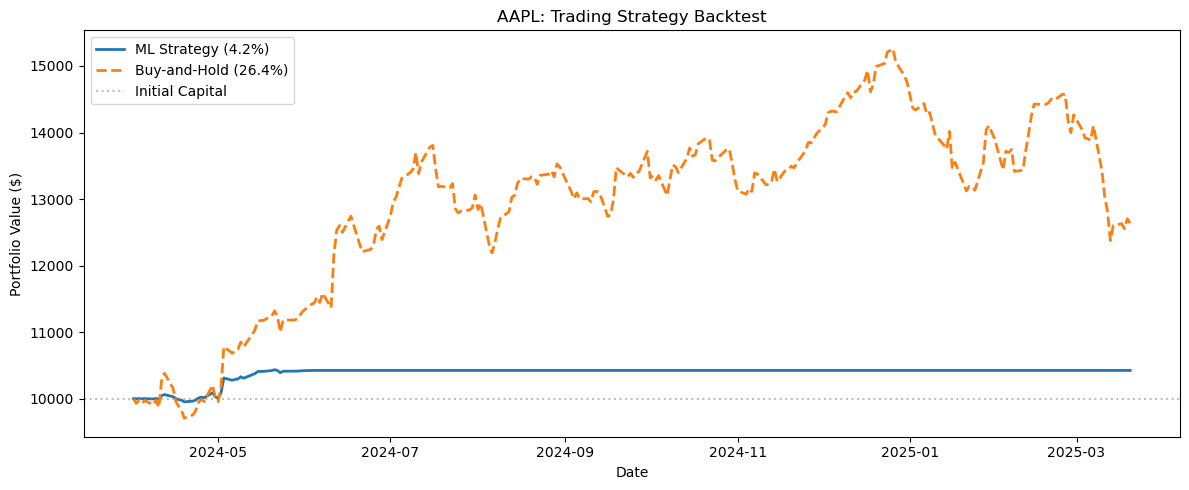

In [22]:
# Buy-and-Hold baseline: buy as many shares as possible on day 1
first_price = prices_list[0]
bh_shares = int(INITIAL_CASH // first_price)
bh_cash = INITIAL_CASH - bh_shares * first_price
bh_values = [bh_cash + bh_shares * p for p in prices_list]

bh_return = ((bh_values[-1] / INITIAL_CASH) - 1) * 100
strategy_return = ((portfolio_values[-1] / INITIAL_CASH) - 1) * 100

print(f"Buy-and-Hold return: {bh_return:.2f}%")
print(f"Strategy return:     {strategy_return:.2f}%")

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dates_list, portfolio_values, label=f"ML Strategy ({strategy_return:.1f}%)", linewidth=2)
ax.plot(dates_list, bh_values, label=f"Buy-and-Hold ({bh_return:.1f}%)", linewidth=2, linestyle="--")
ax.axhline(y=INITIAL_CASH, color="gray", linestyle=":", alpha=0.5, label="Initial Capital")
ax.set_title(f"{TICKER}: Trading Strategy Backtest")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value ($)")
ax.legend()
plt.tight_layout()
plt.show()